# Lunar Subsurface Ice Detection from Chandrayaan-2 DFSAR  (v2)

### Real-calibrated, physics-gated compact-polarimetry pipeline with full validation

**Objective.** Detect subsurface water-ice in shadowed south-pole craters from
Chandrayaan-2 DFSAR L-band compact polarimetry, validate the detector, and
geocode the result onto a lunar map grid.

**Method.** A single specular reflection inverts circular polarization handedness
(CPR < 1). Volumetric and coherent-backscatter returns from fractured ice preserve
handedness (CPR > 1); surface roughness does the same, so the Degree of
Polarization resolves the ambiguity (ice depolarizes, low DOP). Discriminator:
**CPR > 1.0 and DOP < 0.13**. With no in-situ ground truth, the detector is trained
on synthetic compact-pol scenes whose statistics are calibrated to the observed
DFSAR distributions, then applied to real data under a physical admissibility gate.

**Notebook stages.** Synthetic data and calibration check; training; validation
(quantitative comparison, ROC/PR, calibration, confusion, threshold sensitivity,
learned decision boundary, per-scene IoU with bootstrap CI, saliency, qualitative);
model export; real DFSAR application with m-chi decomposition, CPR-DOP density,
incidence-angle dependence, physics-gated mapping, and geocoding.


## 1. Setup

In [1]:
import os, sys, glob, json, time
import numpy as np
import matplotlib.pyplot as plt
import torch

PROJECT_ROOT = os.path.abspath(os.getcwd())
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

from src.synth import SceneConfig, make_compact_dataset, COMPACT_CHANNELS
from src.polarimetry import (ice_threshold_mask, physics_gate,
                             stokes_from_compact, mchi_decomposition)
from src.train import (ChannelNormalizer, TrainConfig, train_model, predict,
                       pixel_metrics, baseline_metrics)
from src.dataio import (dfsar_compact_features, predict_scene,
                        find_compact_slc_in_zip, read_complex_band)
from src import evaluation as ev
from src import geocode as gc
import rasterio
from rasterio.windows import Window

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("PyTorch", torch.__version__, "| compute device:", DEVICE)
os.makedirs("models", exist_ok=True)
os.makedirs("outputs/figures_v2", exist_ok=True)
FIG = "outputs/figures_v2"


PyTorch 2.5.1+cu121 | compute device: cuda


## 2. Configuration

In [2]:
scene = SceneConfig(height=128, width=128, looks=6,
                    ice_fraction=0.04, rough_fraction=0.18,
                    stats_profile="real", difficulty=0.7)   # realistic, non-trivial task

N_TRAIN, N_VAL, N_TEST = 3000, 400, 400
tcfg = TrainConfig(epochs=120, batch_size=24, base_width=32, depth=4,
                   w_dice=1.0, w_phys=0.5, patience=20, device=DEVICE)

CPR_IDX, DOP_IDX = 0, 1
print("channels:", COMPACT_CHANNELS, "| scenes (train/val/test):", N_TRAIN, N_VAL, N_TEST)


channels: ['CPR', 'DOP'] | scenes (train/val/test): 3000 400 400


## 3. Recalibrated synthetic dataset

In [3]:
t0 = time.time()
Xtr, Ytr = make_compact_dataset(N_TRAIN, scene, seed=1)
Xva, Yva = make_compact_dataset(N_VAL,   scene, seed=2)
Xte, Yte = make_compact_dataset(N_TEST,  scene, seed=3)
print("generated %d scenes in %.1fs" % (N_TRAIN+N_VAL+N_TEST, time.time()-t0))
print("ice fraction = %.3f | CPR median %.3f | DOP median %.3f"
      % (Ytr.mean(), np.median(Xtr[:, 0]), np.median(Xtr[:, 1])))


generated 3800 scenes in 38.8s
ice fraction = 0.040 | CPR median 0.243 | DOP median 0.590


### Calibration check: synthetic vs real CPR/DOP

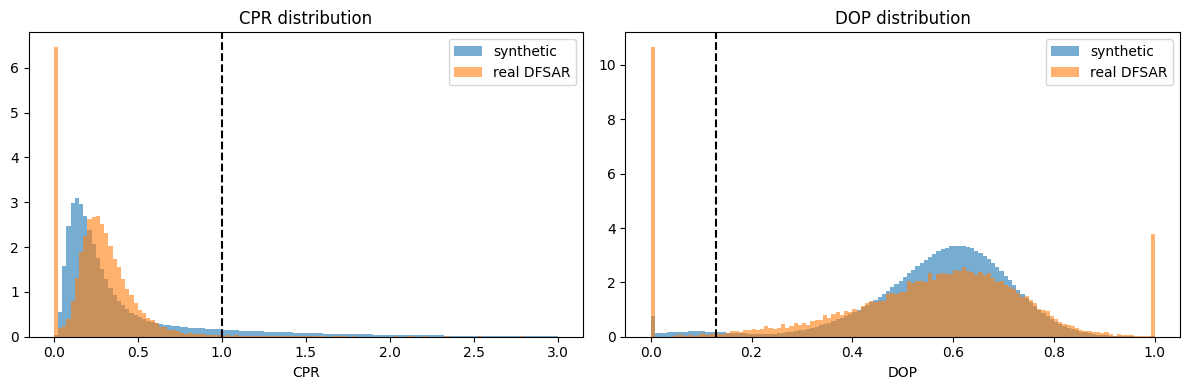

In [4]:
zips = sorted(glob.glob("data/raw/dfsar/*.zip"))
assert zips, "No DFSAR products in data/raw/dfsar/."
ref = dfsar_compact_features(zips[0], az_start=196445, az_len=12000, looks=9)
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].hist(Xtr[:, 0].ravel(), bins=120, range=(0, 3), density=True, alpha=0.6, label="synthetic")
ax[0].hist(ref["cpr"].ravel(), bins=120, range=(0, 3), density=True, alpha=0.6, label="real DFSAR")
ax[0].axvline(1.0, ls="--", c="k"); ax[0].set_xlabel("CPR"); ax[0].set_title("CPR distribution"); ax[0].legend()
ax[1].hist(Xtr[:, 1].ravel(), bins=120, range=(0, 1), density=True, alpha=0.6, label="synthetic")
ax[1].hist(ref["dop"].ravel(), bins=120, range=(0, 1), density=True, alpha=0.6, label="real DFSAR")
ax[1].axvline(0.13, ls="--", c="k"); ax[1].set_xlabel("DOP"); ax[1].set_title("DOP distribution"); ax[1].legend()
plt.tight_layout(); plt.savefig(FIG + "/calibration_check.png", dpi=150, bbox_inches="tight"); plt.show()


## 4. Normalization and deterministic baseline

In [5]:
norm = ChannelNormalizer(log_channels=(CPR_IDX,)).fit(Xtr)
Xtr_n, Xva_n, Xte_n = norm.transform(Xtr), norm.transform(Xva), norm.transform(Xte)
base = baseline_metrics(Xte, Yte, cpr_idx=CPR_IDX, dop_idx=DOP_IDX)
print("Deterministic detector (CPR>1.0 & DOP<0.13) on test set:")
for k in ["iou", "f1", "precision", "recall", "accuracy"]:
    print("  %-10s %.3f" % (k, base[k]))


Deterministic detector (CPR>1.0 & DOP<0.13) on test set:
  iou        0.458
  f1         0.629
  precision  0.997
  recall     0.459
  accuracy   0.978


## 5. Training
Per-epoch loss and validation metrics are printed as training proceeds.

In [6]:
model, history, best_val_iou, best_thr = train_model(
    Xtr_n, Ytr, Xva_n, Yva, tcfg, cpr_idx=CPR_IDX, dop_idx=DOP_IDX, verbose=True)
print("\nbest validation IoU = %.3f at decision threshold %.2f" % (best_val_iou, best_thr))


epoch   1/120 | loss 1.2199 | val IoU 0.991 | F1 0.995 | AUC 1.000 | thr 0.56
epoch   2/120 | loss 0.6025 | val IoU 0.997 | F1 0.998 | AUC 1.000 | thr 0.77
epoch   3/120 | loss 0.2087 | val IoU 0.995 | F1 0.998 | AUC 1.000 | thr 0.42
epoch   4/120 | loss 0.0797 | val IoU 0.998 | F1 0.999 | AUC 1.000 | thr 0.50
epoch   5/120 | loss 0.0425 | val IoU 0.999 | F1 0.999 | AUC 1.000 | thr 0.71
epoch   6/120 | loss 0.0274 | val IoU 0.999 | F1 0.999 | AUC 1.000 | thr 0.38
epoch   7/120 | loss 0.0196 | val IoU 0.999 | F1 0.999 | AUC 1.000 | thr 0.52
epoch   8/120 | loss 0.0151 | val IoU 0.999 | F1 0.999 | AUC 1.000 | thr 0.71
epoch   9/120 | loss 0.0122 | val IoU 0.999 | F1 0.999 | AUC 1.000 | thr 0.86
epoch  10/120 | loss 0.0102 | val IoU 0.999 | F1 0.999 | AUC 1.000 | thr 0.56
epoch  11/120 | loss 0.0087 | val IoU 0.999 | F1 0.999 | AUC 1.000 | thr 0.10
epoch  12/120 | loss 0.0075 | val IoU 0.999 | F1 0.999 | AUC 1.000 | thr 0.58
epoch  13/120 | loss 0.0065 | val IoU 0.999 | F1 0.999 | AUC 1.0

### Training history

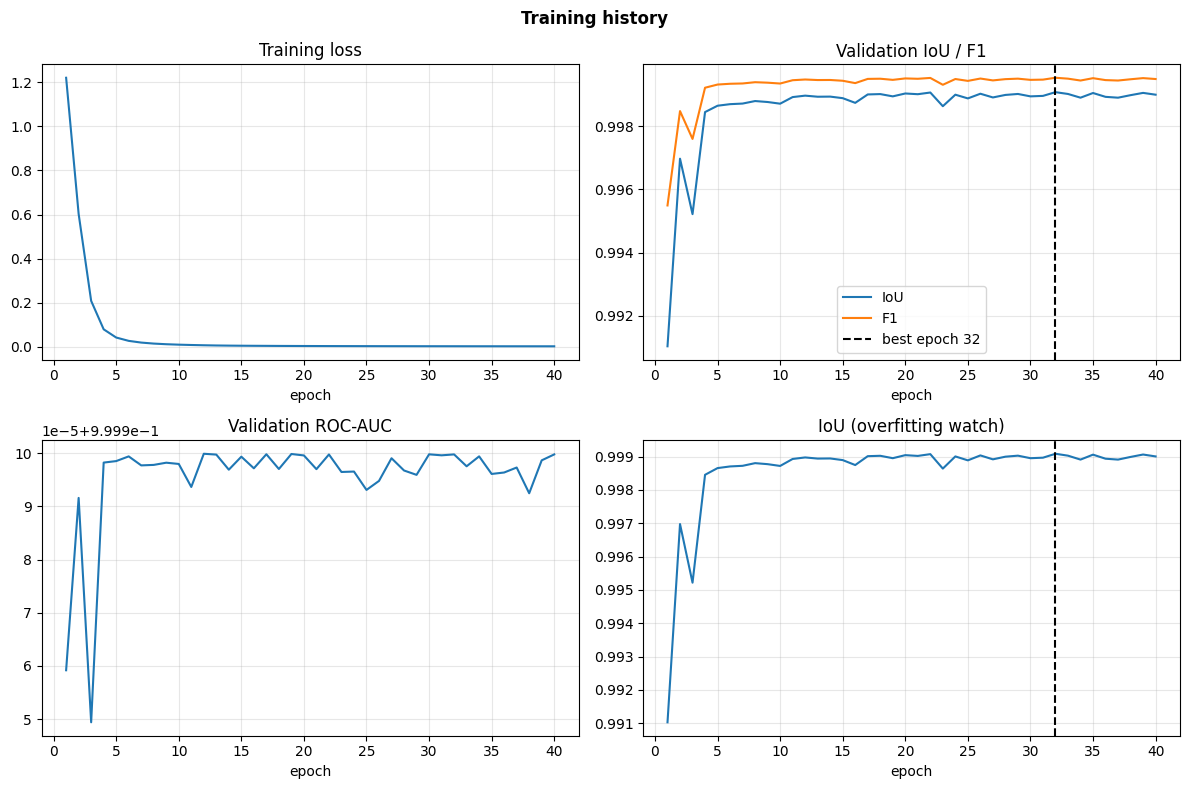

In [7]:
ev.plot_training_curves(history, save=FIG + "/training_curves.png"); plt.show()

## 6. Validation

### 6.1 Quantitative comparison (deterministic / U-Net / physics-gated)

method                iou       f1 precision   recall specificity      mcc    kappa  roc_auc   pr_auc      ece
deterministic       0.458    0.629    0.997    0.459    1.000    0.669    0.619    0.729    0.479    0.022
U-Net               0.999    1.000    0.999    1.000    1.000    1.000    1.000    1.000    1.000    0.000
U-Net + gate        0.459    0.629    1.000    0.459    1.000    0.670    0.620    0.729    0.481    0.022


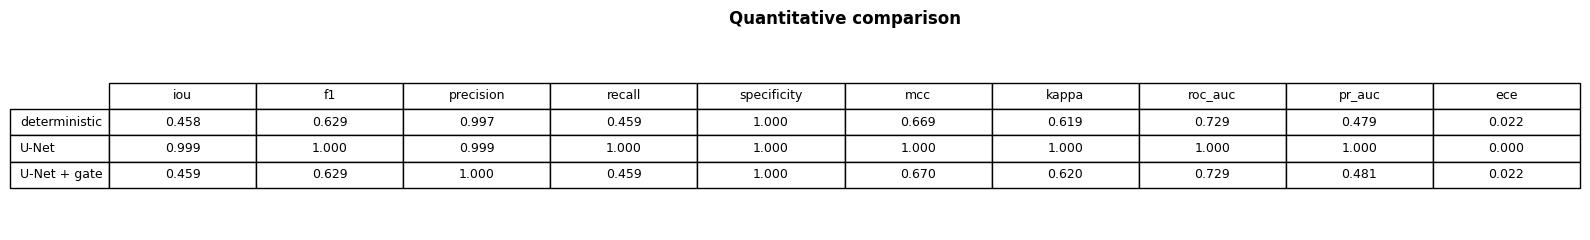

In [8]:
prob_te = predict(model, Xte_n, DEVICE, tcfg.batch_size)
prob_te_gated = physics_gate(prob_te, Xte[:, 0], Xte[:, 1])
rows = {
    "deterministic": ev.extended_metrics(Yte, ice_threshold_mask(Xte[:, 0], Xte[:, 1]).astype(float), 0.5),
    "U-Net":         ev.extended_metrics(Yte, prob_te, best_thr),
    "U-Net + gate":  ev.extended_metrics(Yte, prob_te_gated, best_thr),
}
hdr = ["iou", "f1", "precision", "recall", "specificity", "mcc", "kappa", "roc_auc", "pr_auc", "ece"]
print("%-16s" % "method", *["%8s" % h for h in hdr])
for name, m in rows.items():
    print("%-16s" % name, *["%8.3f" % m.get(h, float('nan')) for h in hdr])
ev.plot_metric_table(rows, save=FIG + "/metric_table.png"); plt.show()


### 6.2 ROC and Precision-Recall

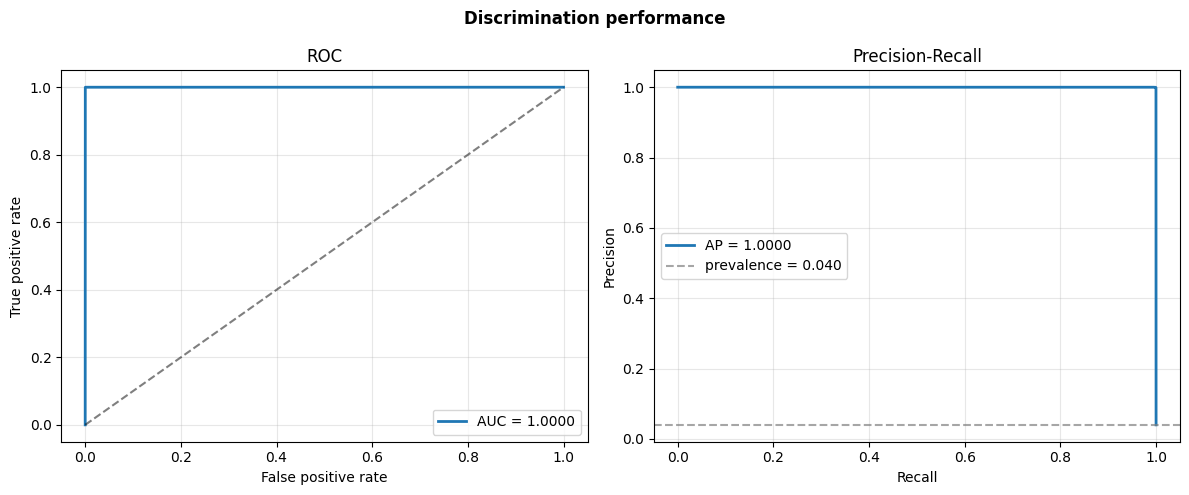

In [9]:
ev.plot_roc_pr(Yte, prob_te, save=FIG + "/roc_pr.png"); plt.show()

### 6.3 Probability calibration

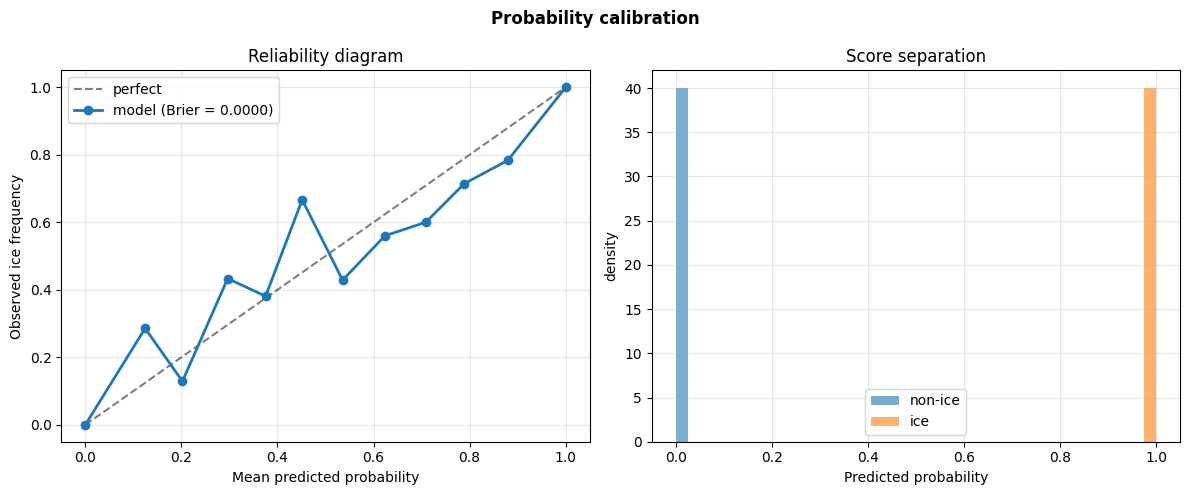

Expected Calibration Error = 0.0001


In [10]:
ev.plot_calibration(Yte, prob_te, save=FIG + "/calibration.png"); plt.show()
print("Expected Calibration Error = %.4f" % ev.expected_calibration_error(Yte, prob_te))


### 6.4 Confusion matrix and threshold sensitivity

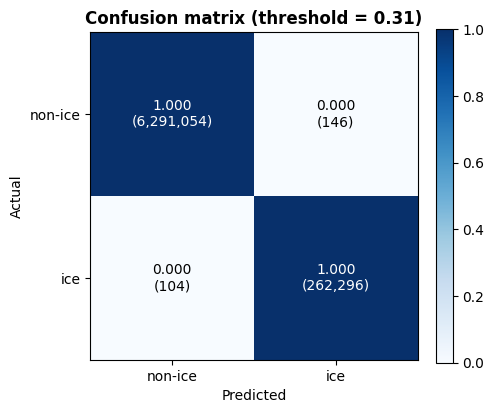

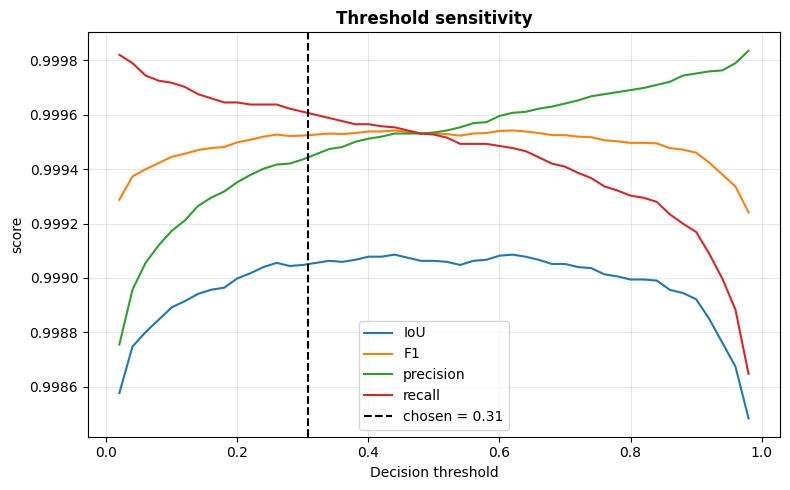

In [11]:
ev.plot_confusion(Yte, prob_te, best_thr, save=FIG + "/confusion.png"); plt.show()
ev.plot_threshold_sweep(Yte, prob_te, chosen=best_thr, save=FIG + "/threshold_sweep.png"); plt.show()


### 6.5 Learned decision boundary in CPR-DOP space

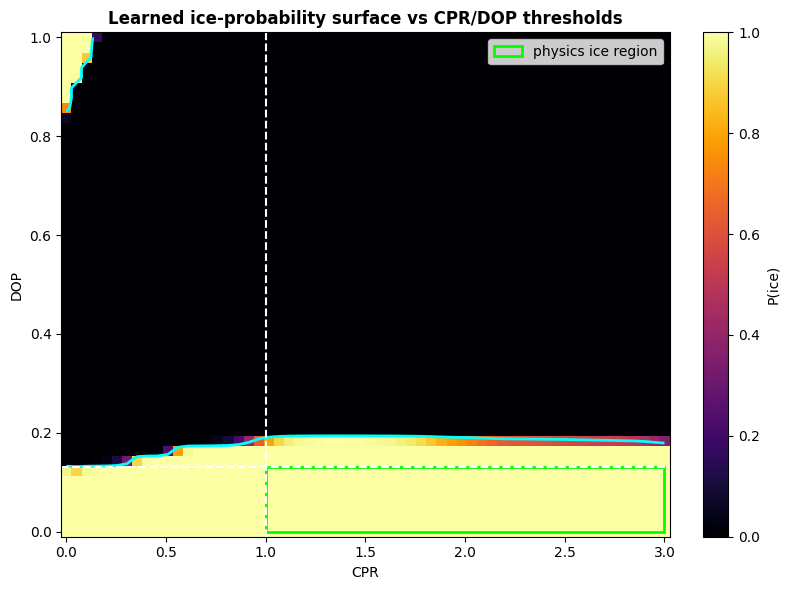

In [12]:
ev.plot_decision_boundary(model, norm, DEVICE, save=FIG + "/decision_boundary.png"); plt.show()

### 6.6 Per-scene IoU and bootstrap confidence interval

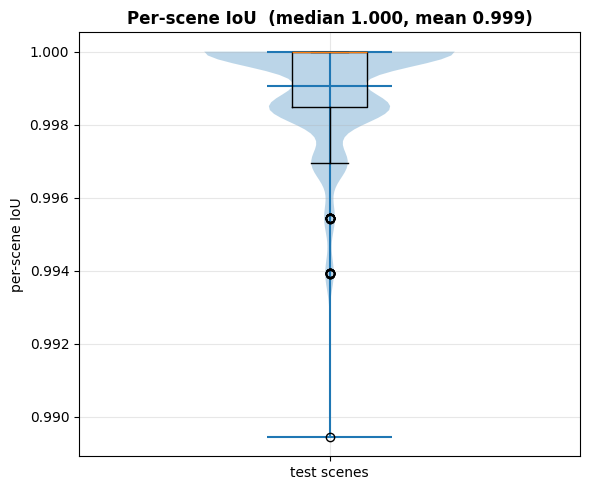

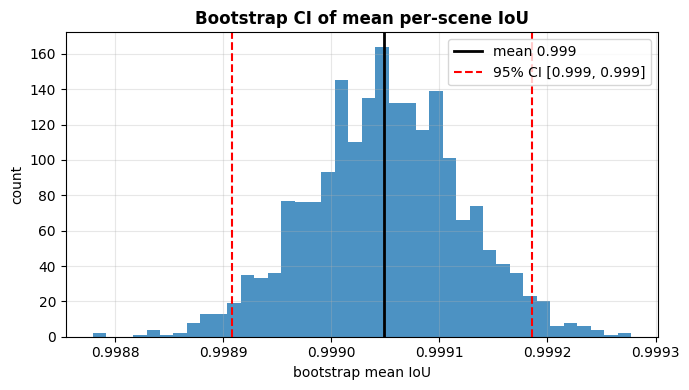

mean per-scene IoU 0.999 | 95% CI [0.999, 0.999]


In [13]:
_, ious = ev.per_scene_iou(model, norm, Xte, Yte, DEVICE, best_thr, save=FIG + "/per_scene_iou.png"); plt.show()
_, ci = ev.bootstrap_scene_ci(ious, save=FIG + "/bootstrap_ci.png"); plt.show()
print("mean per-scene IoU %.3f | 95%% CI [%.3f, %.3f]" % (ious.mean(), ci[0], ci[1]))


### 6.7 Input saliency

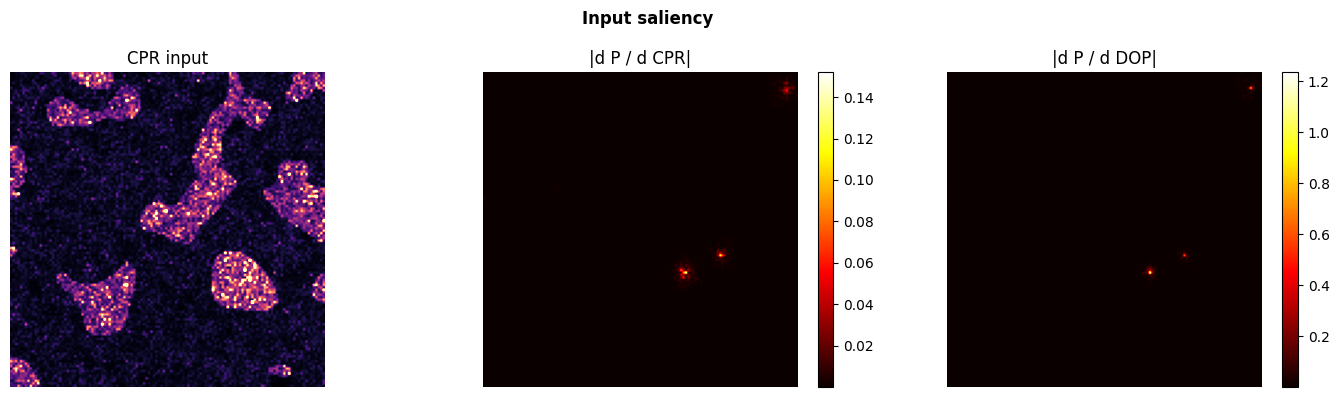

In [14]:
k = int(np.argmax([Yte[i].mean() for i in range(len(Yte))]))
ev.plot_saliency(model, norm, Xte[k], DEVICE, save=FIG + "/saliency.png"); plt.show()


### 6.8 Qualitative results

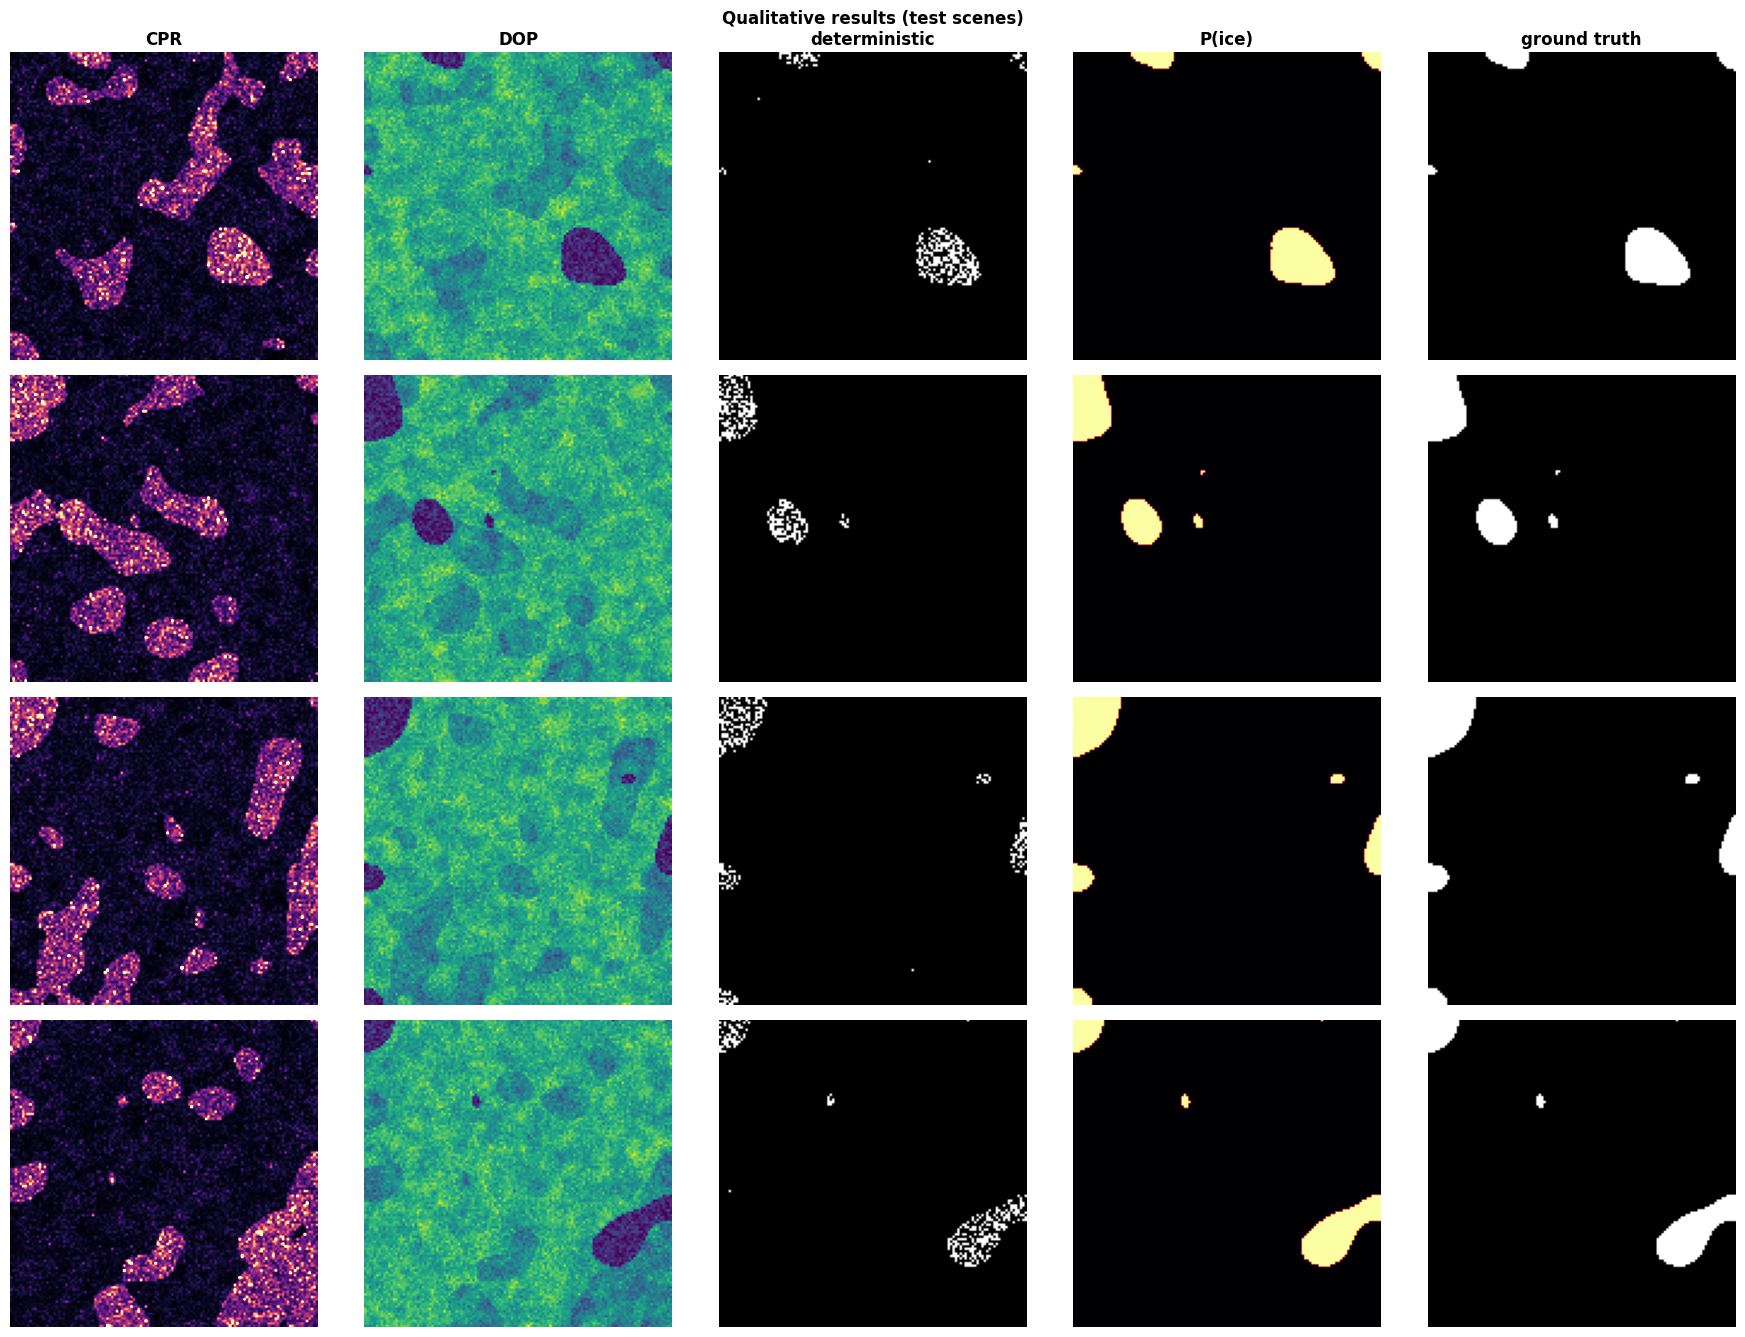

In [15]:
ev.plot_qualitative(model, norm, Xte, Yte, DEVICE, best_thr, n=4, save=FIG + "/qualitative.png"); plt.show()

## 7. Model export

In [16]:
ckpt = {"state_dict": model.state_dict(), "in_ch": 2,
        "base_width": tcfg.base_width, "depth": tcfg.depth,
        "channels": COMPACT_CHANNELS, "best_threshold": float(best_thr),
        "normalizer": norm.state(), "stats_profile": "real"}
torch.save(ckpt, "models/ice_unet_v2.pt")
with open("models/metrics_v2.json", "w") as f:
    json.dump({k: rows[k] for k in rows}, f, indent=2)
with open("models/history_v2.json", "w") as f:
    json.dump(history, f)
print("saved models/ice_unet_v2.pt, models/metrics_v2.json, models/history_v2.json")


saved models/ice_unet_v2.pt, models/metrics_v2.json, models/history_v2.json


## 8. Application to a real DFSAR scene (physics-gated)

In [17]:
SCENE_ZIP = zips[0]
AZ_LEN, LOOKS = 60000, 9

tp = gc.load_tiepoints(SCENE_ZIP)
paths = find_compact_slc_in_zip(SCENE_ZIP)
with rasterio.open(paths["lh"]) as ds:
    H, W = ds.height, ds.width
line_lat = tp["LAT"].mean(axis=1)
az_idx = np.linspace(0, H - 1, tp["naz"])
AZ_START = int(np.clip(int(az_idx[int(np.argmin(line_lat))]) - AZ_LEN // 2, 0, max(0, H - AZ_LEN)))

real = dfsar_compact_features(SCENE_ZIP, az_start=AZ_START, az_len=AZ_LEN, looks=LOOKS)
cpr_r, dop_r, feat = real["cpr"], real["dop"], real["feat"]
prob_r = predict_scene(model, norm, feat, DEVICE, tile=128, overlap=24)
prob_rg = physics_gate(prob_r, cpr_r, dop_r)
print("scene:", os.path.basename(SCENE_ZIP), "| window az", AZ_START, "-", AZ_START + AZ_LEN,
      "| poleward lat %.2f" % line_lat.min())
print("ice coverage: deterministic %.3f%% | ungated %.3f%% | gated %.3f%%"
      % (100*ice_threshold_mask(cpr_r, dop_r).mean(), 100*np.mean(prob_r >= best_thr), 100*np.mean(prob_rg >= best_thr)))


scene: ch2_sar_ncxl_20251026t125618324_d_cp_d18.zip | window az 196445 - 256445 | poleward lat -89.77
ice coverage: deterministic 0.375% | ungated 13.769% | gated 0.249%


### 8.1 m-chi decomposition

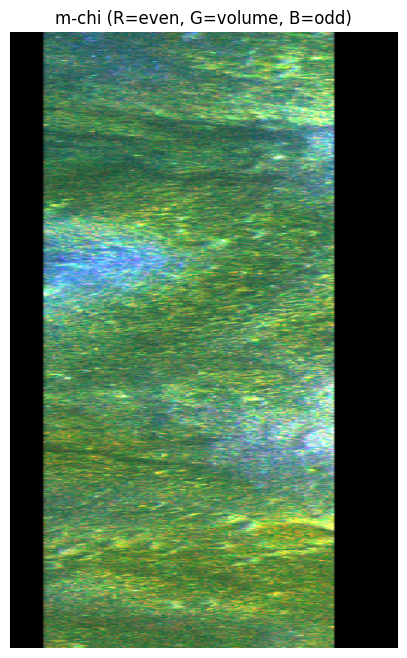

In [18]:
win = Window(0, AZ_START, W, AZ_LEN)
e_h = read_complex_band(paths["lh"], window=win)
e_v = read_complex_band(paths["lv"], window=win)
s1, s2, s3, s4 = stokes_from_compact(e_h, e_v, looks=LOOKS)
rgb = mchi_decomposition(s1[::LOOKS, ::LOOKS], s2[::LOOKS, ::LOOKS], s3[::LOOKS, ::LOOKS], s4[::LOOKS, ::LOOKS])
def sq(a, m=1000): return a[::max(1, a.shape[0]//m)]
plt.figure(figsize=(5, 8)); plt.imshow(sq(rgb), aspect="auto")
plt.title("m-chi (R=even, G=volume, B=odd)"); plt.axis("off")
plt.savefig(FIG + "/real_mchi.png", dpi=150, bbox_inches="tight"); plt.show()


### 8.2 CPR-DOP density and detections

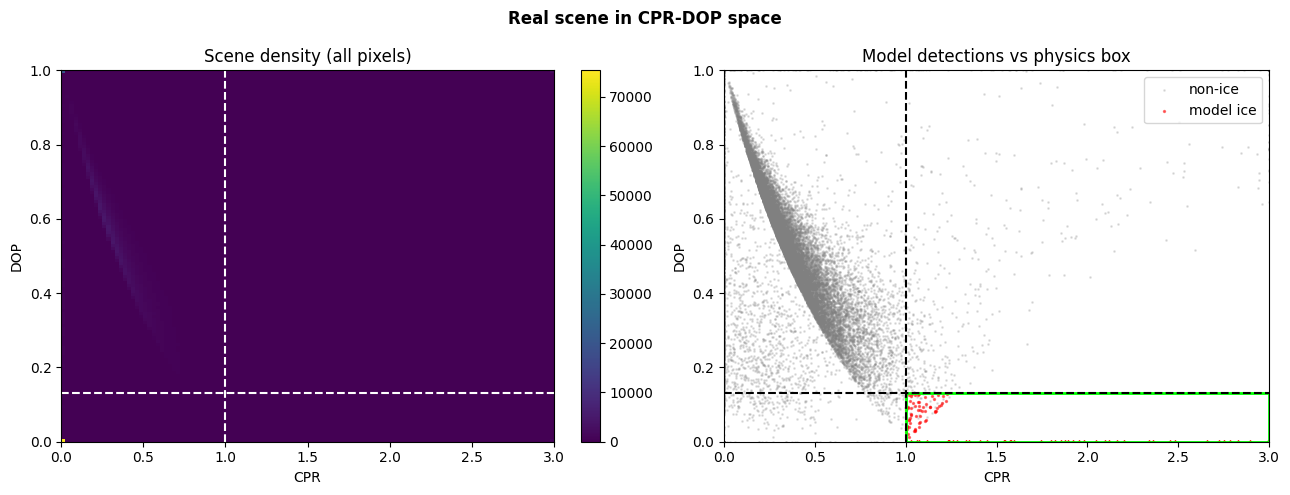

In [19]:
ev.plot_real_cpr_dop_density(cpr_r, dop_r, prob_rg, best_thr, save=FIG + "/real_cpr_dop.png"); plt.show()

### 8.3 Incidence-angle dependence

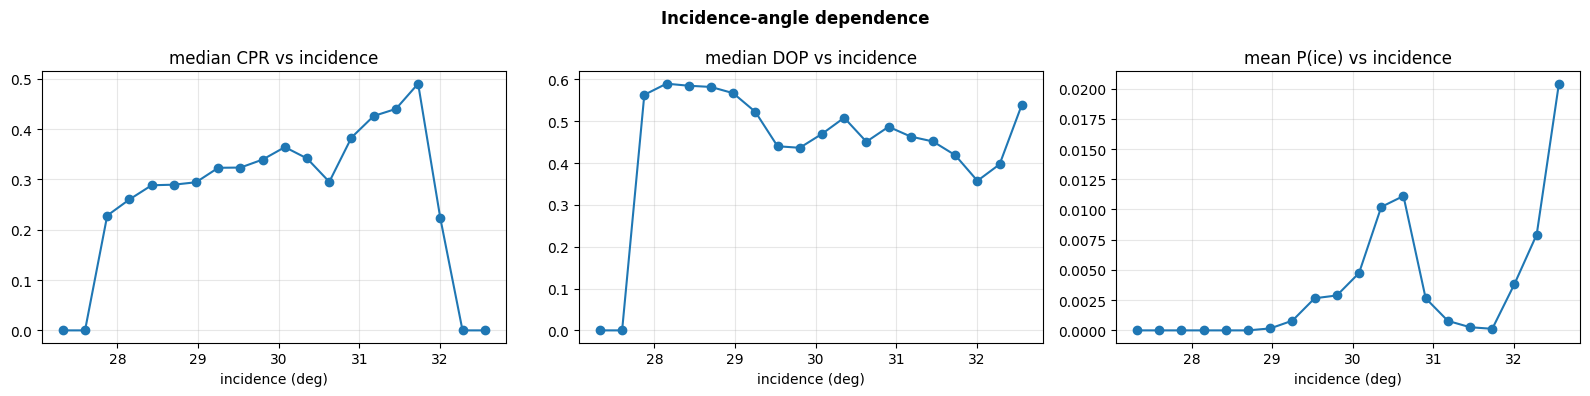

In [20]:
sc = gc.sample_at_tiepoints(tp, cpr_r, AZ_START, AZ_LEN, LOOKS, H, W)
sd = gc.sample_at_tiepoints(tp, dop_r, AZ_START, AZ_LEN, LOOKS, H, W)
sp = gc.sample_at_tiepoints(tp, prob_rg, AZ_START, AZ_LEN, LOOKS, H, W)
ev.plot_incidence_dependence(sc["inc"], sc["val"], sd["val"], sp["val"], save=FIG + "/incidence.png"); plt.show()


### 8.4 Maps and geocoding

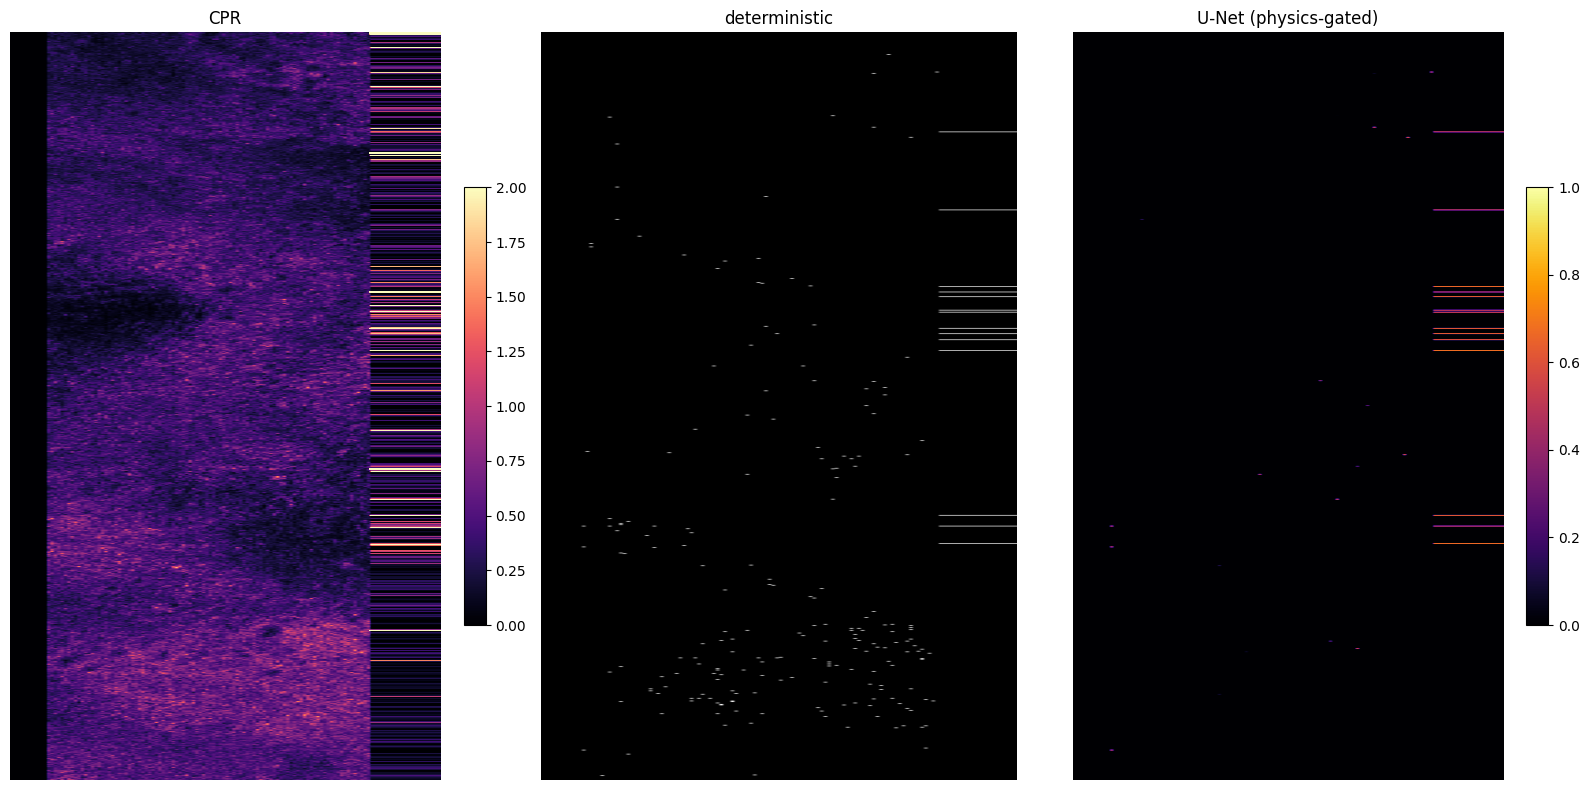

REAL lat/lon bounding box: lat [-89.853, -89.443]  lon [-161.423, -23.748]


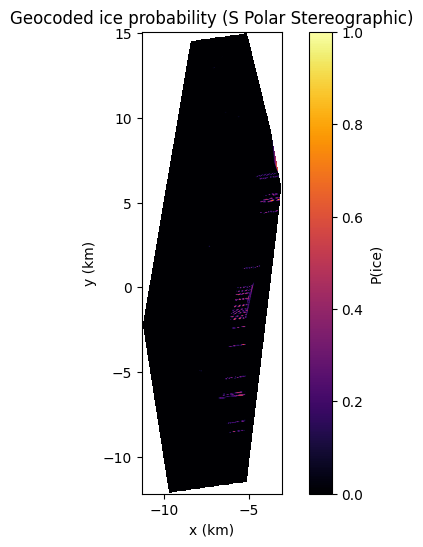

In [21]:
fig, ax = plt.subplots(1, 3, figsize=(16, 8))
im0 = ax[0].imshow(sq(cpr_r), cmap="magma", vmin=0, vmax=2, aspect="auto"); ax[0].set_title("CPR"); ax[0].axis("off"); plt.colorbar(im0, ax=ax[0], fraction=0.046)
ax[1].imshow(sq(ice_threshold_mask(cpr_r, dop_r).astype(float)), cmap="gray", aspect="auto"); ax[1].set_title("deterministic"); ax[1].axis("off")
im2 = ax[2].imshow(sq(prob_rg), cmap="inferno", vmin=0, vmax=1, aspect="auto"); ax[2].set_title("U-Net (physics-gated)"); ax[2].axis("off"); plt.colorbar(im2, ax=ax[2], fraction=0.046)
fig.tight_layout(); fig.savefig(FIG + "/real_maps.png", dpi=150, bbox_inches="tight"); plt.show()

geo = gc.geocode_window(tp, prob_rg, AZ_START, AZ_LEN, LOOKS, H, W, out_px=700)
la0, la1, lo0, lo1 = geo["latlon_bbox"]
print("REAL lat/lon bounding box: lat [%.3f, %.3f]  lon [%.3f, %.3f]" % (la0, la1, lo0, lo1))
gc.save_polar_geotiff("outputs/v2_ice_probability_geocoded.tif", geo["raster"], geo["polar_extent"])
ex = geo["polar_extent"]
plt.figure(figsize=(7, 6))
plt.imshow(geo["raster"], cmap="inferno", vmin=0, vmax=1, origin="lower",
           extent=[ex[0]/1000, ex[1]/1000, ex[2]/1000, ex[3]/1000])
plt.colorbar(label="P(ice)"); plt.xlabel("x (km)"); plt.ylabel("y (km)")
plt.title("Geocoded ice probability (S Polar Stereographic)")
plt.savefig(FIG + "/geocoded.png", dpi=150, bbox_inches="tight"); plt.show()


## 9. Limitations and further work

- The model is trained on synthetic statistics calibrated to a real scene
  window; results are relative ice-likelihood and require validation against
  independent evidence (LEND epithermal-neutron suppression, Diviner thermal
  limits) before any quantitative claim.
- The physics gate enforces the necessary ice condition (CPR>1, DOP<0.13); it
  removes physically impossible detections but does not by itself confirm ice.
- The geocoded GeoTIFF is ready to overlay on co-located OHRC imagery and to
  drive downstream landing-site and traverse planning.

All figures are saved under `outputs/figures_v2/`; the geocoded raster is written
to `outputs/v2_ice_probability_geocoded.tif`.
